Here we will perform two stage model 
1. Stage 1 for filtering low and high coupling
2. predict coupling based on regression analysis

Classification for XGB
Standrdization is optional with XGBoost and random forest classifier but it is necessary with SVM, regression classifier

In [3]:
df = pd.read_csv("../data/808_alpha_shift_dataset.csv")
df.head()

,Filename,Coupling_eV,Diabatic_E1_Ha,Diabatic_E2_Ha,Energy_Gap_eV,Total_Energy_Ha,Overlap_S12,Interlayer_Dist_Ang,FeFe_Dist_Ang,Min_HeavyDist_Ang,...,S12_srsh_cation,S12_qchem_truth,J_eht_eV,J_zindo_eV,J_dftb_eV,S12,S12_sq,absS12,log_absS12,log10_Coupling
0,35_ang_02_02.out,0.385722,-4501.017029,-4501.015720,0.035613,-9002.032748,0.399351,3.499993,3.511410,3.511410,...,-0.041743,NaN,0.070516,0.306738,0.088,-0.041743,0.001743,0.041743,-1.379412,-0.413724
1,35_ang_04.out,0.350921,-4501.016296,-4501.017401,-0.030084,-9002.033697,-0.364585,3.500003,3.522783,3.522783,...,-0.039979,NaN,0.063884,0.305538,NaN,-0.039979,0.001598,0.039979,-1.398170,-0.454788
2,35_ang_04_04.out,0.336474,-4501.022170,-4501.020760,0.038381,-9002.042930,-0.359994,3.499987,3.545420,3.545420,...,-0.036534,NaN,0.051770,0.304035,NaN,-0.036534,0.001335,0.036534,-1.437297,-0.473045
3,35_ang_02.out,0.319848,-4501.019656,-4501.019801,-0.003938,-9002.039457,-0.329370,3.500001,3.505710,3.505710,...,-0.042651,NaN,0.073995,0.307289,NaN,-0.042651,0.001819,0.042651,-1.370070,-0.495053
4,35_ang_06_06.out,0.257368,-4501.025535,-4501.025432,0.002804,-9002.050966,0.297417,3.499980,3.601389,3.541807,...,-0.028680,NaN,0.027681,0.272200,NaN,-0.028680,0.000823,0.028680,-1.542419,-0.589442


In [ ]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("../data/808_alpha_shift_dataset.csv")

X_cols = ["Min_HeavyDist_Ang", "FeFe_Dist_Ang",
          "cos_theta",
          "cos_4phi", "cos_4psi",
        "log_absS12"]

print("Total samples after dropping NAs in features:", len(df))  # should be close to 808

# 2) Build classification label from Coupling_eV, including zeros
#The log10_J_cdft has Nan for zero coupling_eV, so we can use Coupling_eV directly to define the class labels. 
# Example: threshold |Coupling_eV| >= 1e-4 is "large"
threshold_coup = 1e-4 # log10(1e-4) = -4
df["y_class"] = (df["Coupling_eV"].abs() >= threshold_coup).astype(int)

X = df[X_cols].values
y = df["y_class"].values

# 3) Train/test split and classifier as before
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

clf = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)
clf.fit(X_train, y_train)

y_prob = clf.predict_proba(X_test)[:, 1]
threshold_clf = 0.30
y_pred = (y_prob > threshold_clf).astype(int)

acc = accuracy_score(y_test, y_pred)
print(f"\nClassifier Accuracy: {acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Total samples after dropping NAs in features: 808

Classifier Accuracy: 0.8704

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.37      0.49        27
           1       0.89      0.97      0.93       135

    accuracy                           0.87       162
   macro avg       0.80      0.67      0.71       162
weighted avg       0.86      0.87      0.85       162

Confusion Matrix:
[[ 10  17]
 [  4 131]]


TEsT with high thresold and print the classified .csv file

In [27]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- 1. LOAD DATA ---
df = pd.read_csv("../data/808_alpha_shift_dataset.csv")

# --- 2. DEFINE FEATURES AND SAFE TARGET LOG CONVERSION ---
# X_cols = [
#     "FeFe_Dist_Ang", "NN_Dist_1_Ang", "Min_HeavyDist_Ang",
#     "dz", "dx", "dy", "cos_theta",
#     "cos_4phi", "sin_4phi", "cos_4psi", "sin_4psi",
#     "d_lateral", "cos_4alpha", "sin_4alpha",
#     "S12_sq", "log_absS12", "absS12"
# ]
# Cleaned feature list: No redundant mathematical duplicates
X_cols = [
    "FeFe_Dist_Ang", "Min_HeavyDist_Ang", "cos_theta",
    "cos_4phi", "sin_4phi", "cos_4psi", "sin_4psi",
    "d_lateral", "cos_4alpha", "sin_4alpha",
    "log_absS12"  # Kept the log version, dropped absS12 and S12_sq
]
df = df.dropna(subset=X_cols)

# df['log10_abs_Coupling'] = np.log10(df["Coupling_eV"].abs() + 1e-10)
# df["y_class"] = (df["log10_abs_Coupling"] >= -4).astype(int)
df['Coupling_eV'] = np.log10(df["Coupling_eV"].abs() + 1e-10)
df["y_class"] = (df["Coupling_eV"] >= -4).astype(int)
X = df[X_cols].values
y = df["y_class"].values

# --- 3. TRAIN/TEST SPLIT ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# --- 4. TRAIN STANDARD XGBOOST (NO POS WEIGHT) ---
# Removing scale_pos_weight allows the predicted probabilities to represent 
# true structural confidence without artificial skewing.
clf = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)
clf.fit(X_train, y_train)

# --- 5. ENFORCE HIGH-CONFIDENCE REGRESSION FILTER ---
y_prob = clf.predict_proba(X_test)[:, 1]

# By raising this to 0.85, we explicitly reject borderline cases. 
# This will minimize the 17 false positives to protect your R² score.
threshold_clf = 0.95
y_pred = (y_prob > threshold_clf).astype(int)

# --- 6. EVALUATE ---
acc = accuracy_score(y_test, y_pred)
print(f"Classifier Accuracy (Strict Regression Filter @ {threshold_clf}): {acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Low Coupling (0)', 'High Coupling (1)']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# --- 7. BONUS: SHOW HINT FOR DOWNSTREAM REGRESSION DATA ---
# This shows you how many clean samples are moving to your regression step
predicted_high_indices = np.where(y_pred == 1)[0]
actual_high_in_predicted = np.sum(y_test[predicted_high_indices] == 1)
actual_low_in_predicted = np.sum(y_test[predicted_high_indices] == 0)
print("\n Roshan")
print("\n--- Downstream Regression Impact ---")
print(f"Total samples passing to Regression: {len(predicted_high_indices)}")
print(f"Clean High-Coupling samples: {actual_high_in_predicted}")
print(f"Leaked Low-Coupling samples ruining your R²: {actual_low_in_predicted}")

Classifier Accuracy (Strict Regression Filter @ 0.95): 0.8025

Classification Report:
                   precision    recall  f1-score   support

 Low Coupling (0)       0.45      0.78      0.57        27
High Coupling (1)       0.95      0.81      0.87       135

         accuracy                           0.80       162
        macro avg       0.70      0.79      0.72       162
     weighted avg       0.86      0.80      0.82       162

Confusion Matrix:
[[ 21   6]
 [ 26 109]]

 Roshan

--- Downstream Regression Impact ---
Total samples passing to Regression: 115
Clean High-Coupling samples: 109
Leaked Low-Coupling samples ruining your R²: 6


In [28]:
# --- 8. EXTRACT AND SAVE CLEAN REGRESSION DATA ---
# Get probabilities for the ENTIRE dataset (not just the test set)
all_X = df[X_cols].values
df['high_coupling_prob'] = clf.predict_proba(all_X)[:, 1]

# Filter out anything below your strict 0.95 confidence threshold
# This leaves you with a highly pure dataset for regression
regression_ready_df = df[df['high_coupling_prob'] > 0.95]

print(f"\nOriginal dataframe rows: {len(df)}")
print(f"Clean rows exported for regression: {len(regression_ready_df)}")

# Save this to a new file so your regression script can load it directly
regression_ready_df.to_csv("../data/808_high_coupling_regression_set.csv", index=False)
print("Saved clean dataset to '../data/808_high_coupling_regression_set.csv'")


Original dataframe rows: 808
Clean rows exported for regression: 574
Saved clean dataset to '../data/808_high_coupling_regression_set.csv'


In [39]:
#I want to see how accutately predict for training coupling values 
y_prob = clf.predict_proba(X_train)[:, 1]
threshold_clf = 0.30
y_pred = (y_prob > threshold_clf).astype(int)

acc = accuracy_score(y_train, y_pred)
print(f"\nClassifier Accuracy: {acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_train, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_train, y_pred))


Classifier Accuracy: 0.9861

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96       107
           1       0.98      1.00      0.99       539

    accuracy                           0.99       646
   macro avg       0.99      0.96      0.97       646
weighted avg       0.99      0.99      0.99       646

Confusion Matrix:
[[ 98   9]
 [  0 539]]


classifier result summary (BEST RESULT) six feature
clf_threshold = 0.3 (best)
1. X_cols = ["Min_HeavyDist_Ang", "cos_theta", "cos_4phi", "cos_4psi", "S12_sq", "log_absS12"]
Total samples after dropping NAs in features: 808

Classifier Accuracy: 0.8827

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.41      0.54        27
           1       0.89      0.98      0.93       135

    accuracy                           0.88       162
   macro avg       0.84      0.69      0.73       162
weighted avg       0.87      0.88      0.87       162

Confusion Matrix:
[[ 11  16]
 [  3 132]]
 by addin d_lateral with above six_feature
 Total samples after dropping NAs in features: 808

Classifier Accuracy: 0.8704

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.41      0.51        27
           1       0.89      0.96      0.93       135

    accuracy                           0.87       162
   macro avg       0.79      0.69      0.72       162
weighted avg       0.86      0.87      0.86       162

Confusion Matrix:
[[ 11  16]
 [  5 130]]

In [22]:
# Feature importances for classification
importances = pd.Series(clf.feature_importances_, index=X_cols).sort_values(ascending=False)
print("Classifier feature importances:")
print(importances)

Classifier feature importances:
cos_4phi             0.274768
cos_4psi             0.150679
Min_HeavyDist_Ang    0.144521
cos_theta            0.138186
d_lateral            0.107744
NN_Dist_1_Ang        0.106396
FeFe_Dist_Ang        0.077706
dtype: float32


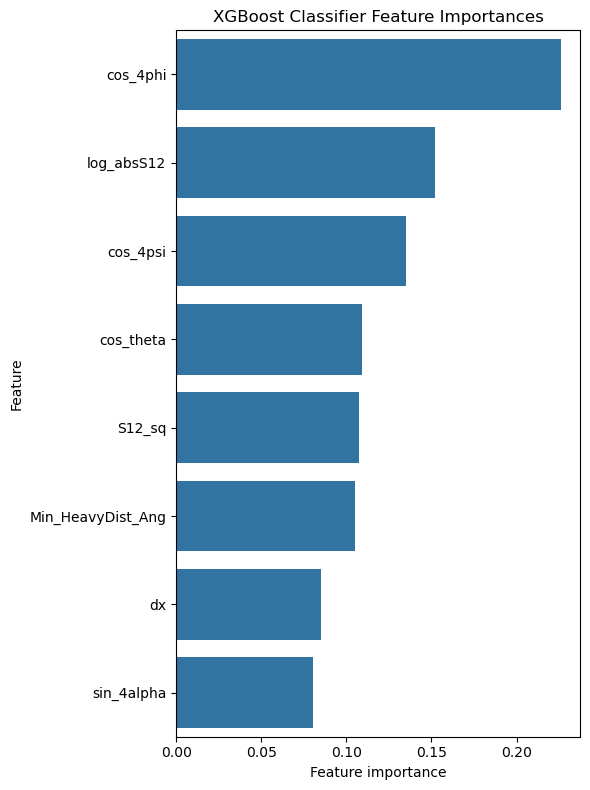

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming you already have:
# importances = pd.Series(clf.feature_importances_, index=X_cols).sort_values(ascending=False)

# Sort (if not already sorted)
importances = importances.sort_values(ascending=False)  # ascending for nicer horizontal plot

plt.figure(figsize=(6, 8))
sns.barplot(x=importances.values, y=importances.index, color="C0")

plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("XGBoost Classifier Feature Importances")
plt.tight_layout()

# Save figure (adjust path if needed)
plt.savefig("../Figure/xgb_8_feature_importances.png", dpi=300)
plt.show()

In [7]:
# ===============================
# 3. CREATE OUTPUT DIR
# ===============================
import os
Results_dir = "../Results"
os.makedirs(Results_dir, exist_ok=True)

KRR regression on large coupling

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_ridge import KernelRidge
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error

# same X_cols as before
df_reg = df.copy()
df_reg = df_reg[df_reg["y_class"] == 1]               # only large couplings
df_reg = df_reg.dropna(subset=["log10_J_cdft"])       # ensure regression target defined

X_reg = df_reg[X_cols].values
y_reg = df_reg["log10_J_cdft"].values

Xtr_r, Xte_r, ytr_r, yte_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

krr = Pipeline([
    ("scaler", StandardScaler()),
    ("krr", KernelRidge(kernel="rbf", alpha=1.0, gamma=0.1))
])

krr.fit(Xtr_r, ytr_r)
y_pred_r = krr.predict(Xte_r)

print("R2:", r2_score(yte_r, y_pred_r))
print("MAE:", mean_absolute_error(yte_r, y_pred_r))


R2: 0.48751301617787846
MAE: 0.36691820596386143


RAndom forest regression feature analysis

Random Forest (regression) feature importances:
absS12               0.211363
log_absS12           0.203834
cos_4phi             0.149656
cos_theta            0.099667
Min_HeavyDist_Ang    0.073228
NN_Dist_1_Ang        0.033638
cos_4psi             0.031701
sin_4alpha           0.027662
sin_4psi             0.024751
dz                   0.024662
FeFe_Dist_Ang        0.024098
cos_4alpha           0.021996
S12_sq               0.020871
sin_4phi             0.016889
dy                   0.014903
d_lateral            0.011313
dx                   0.009768
dtype: float64


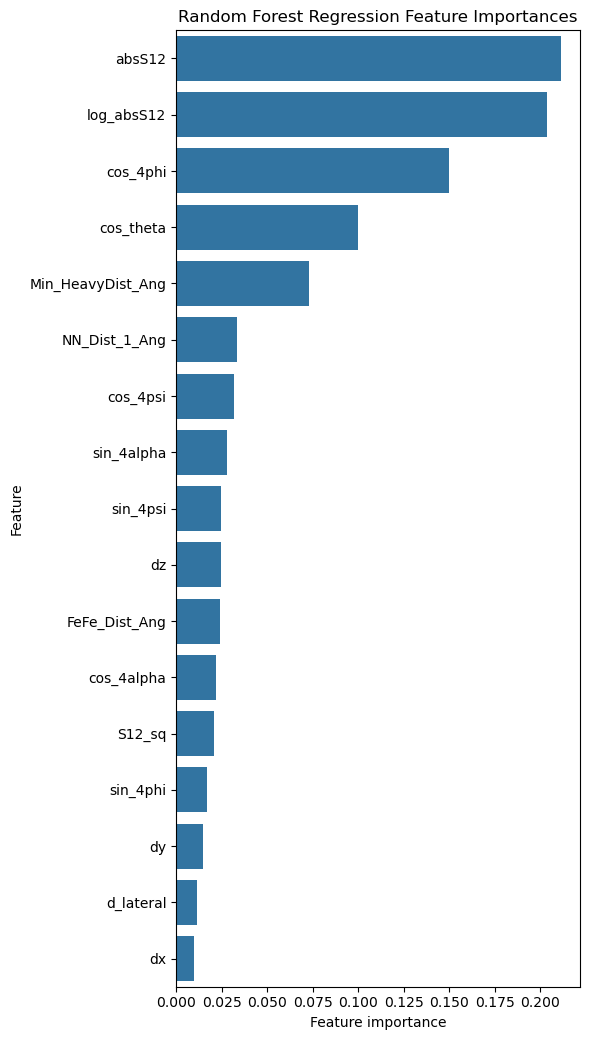

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# -------------------------
# 1. Load data and columns
# -------------------------
df = pd.read_csv("../data/808_master_dataset_v2.csv")

X_cols = ["FeFe_Dist_Ang", "NN_Dist_1_Ang", "Min_HeavyDist_Ang",
          "dz", "dx", "dy", "cos_theta",
          "cos_4phi", "sin_4phi", "cos_4psi", "sin_4psi",
          "d_lateral", "cos_4alpha", "sin_4alpha",
          "S12_sq", "log_absS12", "absS12"]   # or your full feature set for regression

target_col = "log10_J_cdft"

# keep only rows with all needed features and target
df_reg = df.dropna(subset=X_cols + [target_col])

X = df_reg[X_cols].values
y = df_reg[target_col].values

# ----------------------------------
# 2. Train a Random Forest regressor
# ----------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# ----------------------------------
# 3. Feature importances (regression)
# ----------------------------------
importances = pd.Series(rf.feature_importances_, index=X_cols)
importances_sorted = importances.sort_values(ascending=False)

print("Random Forest (regression) feature importances:")
print(importances.sort_values(ascending=False))

# -------------------------
# 4. Plot importances
# -------------------------
plt.figure(figsize=(6, 0.5 * len(X_cols) + 2))
sns.barplot(x=importances_sorted.values, y=importances_sorted.index, color="C0")
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Random Forest Regression Feature Importances")
plt.tight_layout()
plt.savefig("../Figure/rf_reg_feature_importances.png", dpi=300)
plt.show()